### 확률적 경사하강법 SGD
- 모델의 오차(비용)를 최소하는 파라미터(가중치)를 찾기 위한 최적화 방법
- 현재위치 : 모델의 현재 파라미터 
- 산의 높이 : 모델의 오차
- 기울기 : 반대방향으로 가야 가장 빠르게 낮아진다

##### <종류>
- 배치 경사하강법 : 산 전체의 지형을 모두 조사해서 가장 가파른 방향을 찾아 한걸음씩 내려가는 구조
  - 장점 : 한번에 전체 데이터를 다 써서 기울기를 계산하므로 기울기 계산이 매우 정확
  - 단점 : 데이터가 많으면 매우 느리고 리소스를 많이 사용

- 확률적 경사하강법 (SGD) : 무작위로 한 지점만 보고 그곳의 경사를 따라서 내려간다
- SGD : 무작위로 샘플 한개의 오차를 계산하고 파라미터를 업데이트. 이과정을 모든 데이터에 대해서 빠르게 반복
  - 무작위성의 장점 : 지역최저점 (local minimum)에 갇히지 않고 더 낮은 전역 최저점(global minimum) 

   W_new = W_old - η * ∇J(W_old; x^(i); y^(i))

  - W_new : 새로운 가중치
  - W_old : 현재 가중치
  - η(에타) : 학습률 learning late : 너무 크면 최적점을 지나고, 너무 작으면 학습이 매우 느려진다 
    (ex. 학습률이 크면 가장 하단의 꼭짓점(?)을 못찾음. 학습률이 작으면 하단의 꼭짓점을 정확하게 찾지만 오래걸림)
    (ex. 그래서 처음에는 학습률을 크게해서 움직이다 학습률이 가파라지는 영역에서는 촘촘하게 움직일 수 있도록 하는게 있음)
  - ∇(나불라) : 기울기 gradient  
  - J : 오차함수(비용함수) 현재가중치 W-old에서 하나의 데이터샘플에 대한 오차
      -  ∇J(W_old) : “오차가 커지는 방향”
      -  –∇J(W_old) : “오차가 줄어드는 방향(내리막길)”
  - 새로운 가중치 = 현재가중치에서 오차가 커지는 방향의 반대로 학습률 만큼 이동

In [1]:
# y = wx 
# 비용함수의 오차 (Wx-y)**2 /2 tntlrdmf alqns (Wx-y)*x
# 공부시간 x 시험점수 y
# 3시간 공부하고, 점수7 (3,7) W-old = 1.0 학습률 η=0.1
# y_pred = 1.0 X 3
# 기울기 계산 (3.0 - 7)x3 = -12.0
# 1.0 - (0.1 x -12.0) = 1.0 + 1.2 = 2.2

# # 5시간 점수10 (5,10)
# ((2.2 x 5(시간)) - 10 ) x 5 = 5 (기울기)
# 이전 기울기에서 새로운 학습률을 빼줌..?? 

# 무슨말이야???????????????????????

epoch : 1, loss : 2.0817, w 가중치 : 0.2502, b: -0.2935
epoch : 11, loss : 0.5442, w 가중치 : 1.8829, b: 0.2243
epoch : 21, loss : 0.2068, w 가중치 : 2.0502, b: 0.4881
epoch : 31, loss : 0.0683, w 가중치 : 2.1040, b: 0.6754
epoch : 41, loss : 0.0251, w 가중치 : 2.1067, b: 0.7779
epoch : 51, loss : 0.0075, w 가중치 : 2.0964, b: 0.8507
epoch : 61, loss : 0.0050, w 가중치 : 2.0848, b: 0.8680
epoch : 71, loss : 0.0022, w 가중치 : 2.0842, b: 0.8919
epoch : 81, loss : 0.0000, w 가중치 : 2.0779, b: 0.9432
epoch : 91, loss : 0.0001, w 가중치 : 2.1023, b: 0.9284


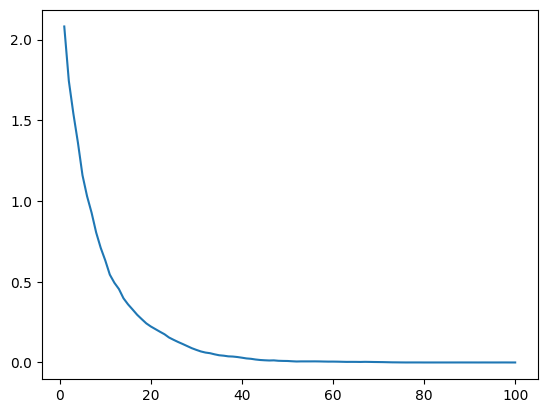

In [2]:
# learning rate 학습률 : 기울기의 방향으로 다음 가중치 업데이트 양
# epoch # 몇번 학습 
import numpy as np
import matplotlib.pyplot as plt

# 샘플데이터 : 정답 y = 2x + 1 
X = 2*np.random.randn(100,1)
y = 2*X + 1 + np.random.randn(100,1) #약간의 노이즈 추가

# SGD를 위한 초기값 세팅
w = np.random.randn(1,1)  #가중치(기울기)
b = np.random.randn(1,1)  #y절편
learning_rate = 0.0005
n_epochs = 100
history = []
loss = []

# 학습반복
for epoch in range(n_epochs):
    # epoch마다 데이터 샘플을 하나씩 학습
    for i in range(len(X)):
        random_idx = np.random.randint(len(X))
        xi = X[random_idx:random_idx+1]
        yi = y[random_idx:random_idx+1]
        # 예측 y_pred = Wx + b
        y_pred = xi.dot(w) + b

        # 오차 계산
        error = y_pred - yi

        # 수식적용 : 기울기 계산
        gradient_w = xi.T.dot(error)
        gradient_b = np.sum(error)

        # 수식적용 : 가중치와 편향 업데이트
        w = w - learning_rate*gradient_w
        b = b - learning_rate*gradient_b

        history.append( ( w.copy()[0,0], b.copy()[0,0] ) )  #시각화를 위해서 저장

    #epoch 단위로 결과 출력
    total_loss = np.mean(X.dot(w) + b - y)**2
    loss.append(total_loss)
    if epoch % 10 == 0 :
        print(f'epoch : {epoch+1}, loss : {total_loss:.4f}, w 가중치 : {w[0,0]:.4f}, b: {b[0,0]:.4f}')


plt.plot(range(1,n_epochs+1), loss)

In [3]:
# SGD
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor()
X.shape, y.shape
sgd.fit(X,y)

d:\0python_SNC\streamlit_prj\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [4]:
sgd.predict(X)[:5], y[:5], sgd.intercept_, sgd.coef_   # X : 예측 / y: 실제 정답?? 

(array([ 5.72738985, -0.47818328,  2.59708923,  1.66980931,  4.43005517]),
 array([[6.718861  ],
        [0.8206997 ],
        [2.53566009],
        [1.72552703],
        [5.14489834]]),
 array([0.91749696]),
 array([2.10810449]))

In [5]:
print(w, b)
predict = w*X + b
predict[:5]

[[2.07532703]] [[0.94038091]]


array([[ 5.6754881 ],
       [-0.43359886],
       [ 2.59385836],
       [ 1.68099608],
       [ 4.39832478]])

In [6]:
%pip install Pillow

Note: you may need to restart the kernel to use updated packages.


--- SGD 학습 시작 ---
Epoch  1 | Loss: 0.9538 | W: 1.4792, b: 1.8316
Epoch  2 | Loss: 0.8693 | W: 1.4159, b: 1.4113
Epoch  3 | Loss: 0.8347 | W: 1.6117, b: 1.2250
Epoch  4 | Loss: 0.8092 | W: 1.8373, b: 1.1190
Epoch  5 | Loss: 0.8202 | W: 1.7932, b: 1.0777
Epoch  6 | Loss: 0.8368 | W: 1.8656, b: 1.2897
Epoch  7 | Loss: 0.8171 | W: 1.8519, b: 1.0476
Epoch  8 | Loss: 0.8328 | W: 1.5885, b: 1.2651
Epoch  9 | Loss: 0.8323 | W: 1.6837, b: 1.4483
Epoch 10 | Loss: 0.8313 | W: 1.5510, b: 1.3325

--- SGD 학습 완료 ---
최종 W: 1.5510 (정답: 2.0)
최종 b: 1.3325 (정답: 1.0)


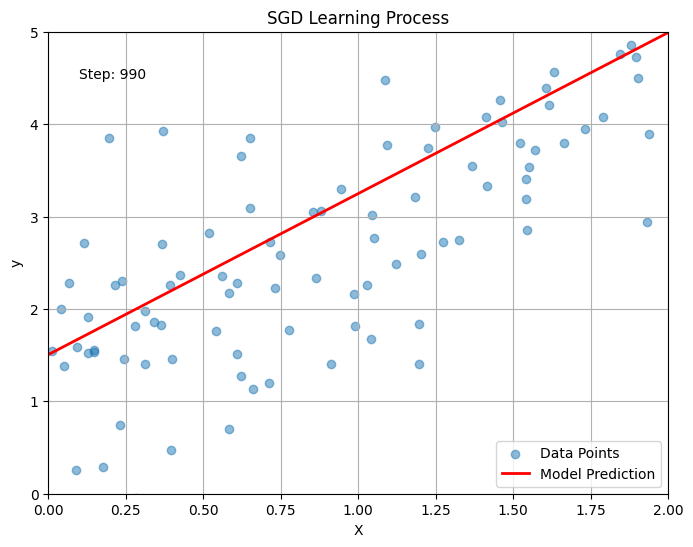

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# 1. 샘플 데이터 생성 (정답: y = 2x + 1)
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 1 + 2 * X + np.random.randn(100, 1) # 약간의 노이즈 추가

# 2. SGD 적용을 위한 초기값 설정
W = np.random.randn(1, 1) # 가중치 (기울기)
b = np.random.randn(1, 1) # 편향 (y절편)
learning_rate = 0.05
n_epochs = 10

# 학습 과정을 기록할 리스트
history = []

# 3. 정답을 찾아가는 과정 반복 묘사
print("--- SGD 학습 시작 ---")
for epoch in range(n_epochs):
    # 매 Epoch마다 데이터 샘플 하나씩 학습
    for i in range(len(X)):
        # 랜덤하게 하나의 샘플 선택
        random_index = np.random.randint(len(X))
        xi = X[random_index:random_index+1]
        yi = y[random_index:random_index+1]

        # 예측 (y_pred = W*x + b)
        y_pred = xi.dot(W) + b

        # 오차 계산
        error = y_pred - yi

        # 수식 적용: 기울기 계산
        gradient_W = xi.T.dot(error)
        gradient_b = np.sum(error)

        # 수식 적용: 가중치와 편향 업데이트
        W = W - learning_rate * gradient_W
        b = b - learning_rate * gradient_b

        # 시각화를 위해 10번의 업데이트마다 기록
        if i % 10 == 0:
            history.append((W.copy()[0,0], b.copy()[0,0]))
    
    # Epoch마다 결과 출력
    total_loss = np.mean((X.dot(W) + b - y)**2)
    print(f"Epoch {epoch+1:2d} | Loss: {total_loss:.4f} | W: {W[0,0]:.4f}, b: {b[0,0]:.4f}")

print("\n--- SGD 학습 완료 ---")
print(f"최종 W: {W[0,0]:.4f} (정답: 2.0)")
print(f"최종 b: {b[0,0]:.4f} (정답: 1.0)")


# 4. 학습 과정 시각화 (애니메이션)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X, y, alpha=0.5, label='Data Points')
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_title("SGD Learning Process")
ax.grid(True)
ax.set_xlim(0, 2)
ax.set_ylim(0, 5)

X_line = np.array([[0], [2]])
line, = ax.plot([], [], 'r-', lw=2, label='Model Prediction')
epoch_text = ax.text(0.05, 0.9, '', transform=ax.transAxes)
ax.legend()

def update(frame):
    W_val, b_val = history[frame]
    y_line = X_line * W_val + b_val
    line.set_data(X_line, y_line)
    epoch_text.set_text(f'Step: {frame*10}')
    return line, epoch_text

# 애니메이션 생성
ani = FuncAnimation(fig, update, frames=len(history), blit=True, interval=50)

# GIF로 저장 (Pillow가 설치되어 있어야 합니다: pip install Pillow)
ani.save('sgd_learning.gif', writer=PillowWriter(fps=10))

# plt.show()

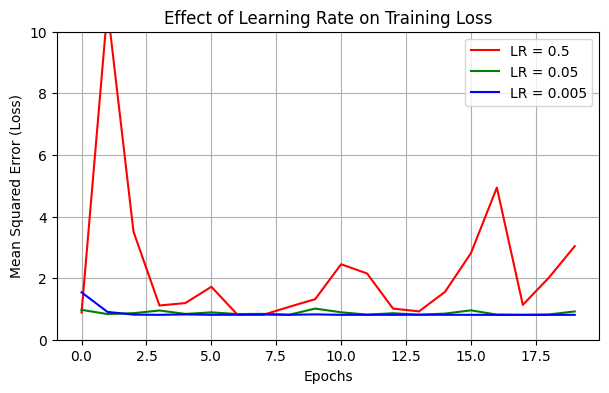

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 샘플 데이터 생성 (정답: y = 2x + 1)
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 1 + 2 * X + np.random.randn(100, 1)

# 2. 비교할 학습률 리스트
learning_rates = [0.5, 0.05, 0.005]
colors = ['red', 'green', 'blue']
n_epochs = 20

plt.figure(figsize=(7, 4))

# 3. 각 학습률에 대해 SGD 학습 반복
for lr, color in zip(learning_rates, colors):
    W = np.random.randn(1, 1)
    b = np.random.randn(1, 1)
    loss_history = []

    for epoch in range(n_epochs):
        # 매 Epoch마다 데이터 샘플 하나씩 학습
        for i in range(len(X)):
            random_index = np.random.randint(len(X))
            xi = X[random_index:random_index+1]
            yi = y[random_index:random_index+1]

            y_pred = xi.dot(W) + b
            error = y_pred - yi
            gradient_W = xi.T.dot(error)
            gradient_b = np.sum(error)

            W = W - lr * gradient_W
            b = b - lr * gradient_b

        # Epoch별 손실(loss) 계산 및 기록
        total_loss = np.mean((X.dot(W) + b - y)**2)
        loss_history.append(total_loss)

    # 4. 결과 시각화
    plt.plot(range(n_epochs), loss_history, color=color, label=f'LR = {lr}')

plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Loss)")
plt.title("Effect of Learning Rate on Training Loss")
plt.legend()
plt.grid(True)
plt.ylim(0, 10) # y축 범위를 고정하여 비교 용이하게 함
plt.show()

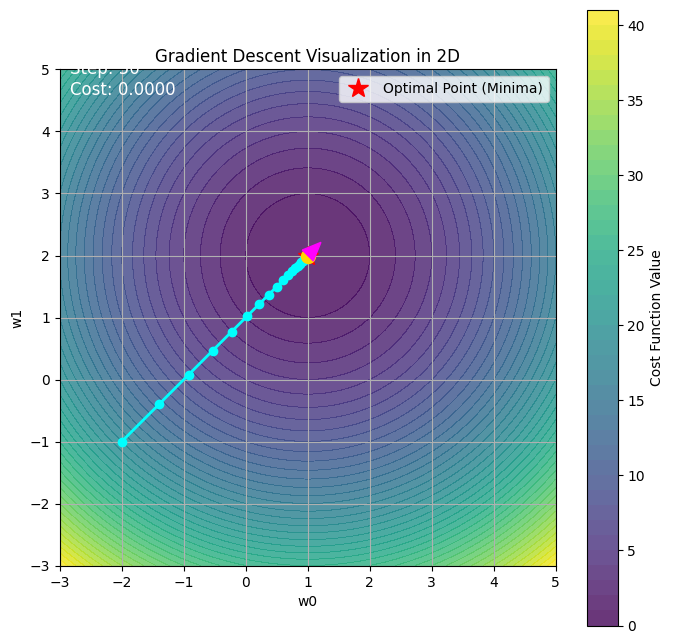

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.cm as cm
from matplotlib.patches import FancyArrow

# 1. 비용 함수 정의
def cost_function(w0, w1):
    return (w0 - 1)**2 + (w1 - 2)**2

# 2. 기울기 함수
def gradient(w0, w1):
    grad_w0 = 2 * (w0 - 1)
    grad_w1 = 2 * (w1 - 2)
    return np.array([grad_w0, grad_w1])

# 3. SGD 설정
learning_rate = 0.1
initial_w = np.array([-2.0, -1.0])
n_steps = 50

# 학습 과정 기록
history = [initial_w.copy()]
current_w = initial_w.copy()
for _ in range(n_steps):
    grad = gradient(current_w[0], current_w[1])
    current_w = current_w - learning_rate * grad
    history.append(current_w.copy())
history = np.array(history)

# 4. 시각화 준비
w0_range = np.linspace(-3, 5, 100)
w1_range = np.linspace(-3, 5, 100)
W0, W1 = np.meshgrid(w0_range, w1_range)
Z = cost_function(W0, W1)

fig, ax = plt.subplots(figsize=(8, 8))
contour = ax.contourf(W0, W1, Z, levels=50, cmap=cm.viridis, alpha=0.8)
fig.colorbar(contour, ax=ax, label='Cost Function Value')
ax.plot(1, 2, 'r*', markersize=15, label='Optimal Point (Minima)')

ax.set_xlabel('w0')
ax.set_ylabel('w1')
ax.set_title('Gradient Descent Visualization in 2D')
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
ax.legend()

# 애니메이션 초기 객체
path_line, = ax.plot([], [], 'o-', color='cyan', markersize=6, linewidth=2, label='GD Path')
current_point, = ax.plot([], [], 'o', color='gold', markersize=10, label='Current Point')
step_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12, color='white')

# 초기 화살표 (None으로 시작)
arrow_patch = None

# 5. 업데이트 함수
def update(frame):
    global arrow_patch
    # 이전 화살표 제거
    if arrow_patch:
        arrow_patch.remove()

    # 경로 업데이트
    path_line.set_data(history[:frame+1, 0], history[:frame+1, 1])
    current_point.set_data([history[frame, 0]], [history[frame, 1]])

    # 기울기 계산 및 화살표 갱신
    if frame > 0:
        current_w_val = history[frame-1]
        grad_val = gradient(current_w_val[0], current_w_val[1])
        arrow_dx = -learning_rate * grad_val[0] * 5
        arrow_dy = -learning_rate * grad_val[1] * 5
        arrow_patch = FancyArrow(
            current_w_val[0], current_w_val[1],
            arrow_dx, arrow_dy,
            width=0.05, head_width=0.25, head_length=0.3,
            color='magenta', zorder=5
        )
        ax.add_patch(arrow_patch)

    # 텍스트 업데이트
    step_text.set_text(f'Step: {frame}\nCost: {cost_function(history[frame,0], history[frame,1]):.4f}')

    return path_line, current_point, step_text

# 6. 애니메이션 생성
ani = FuncAnimation(fig, update, frames=len(history), blit=False, interval=80)

# GIF 저장
ani.save('gradient_descent_2d.gif', writer=PillowWriter(fps=10))
plt.show()